# 02 — Feature Engineering

`src.features`의 공통 코드로 `data/archive` 원본에서 실제 초기 10~100사이클 피처를 생성합니다.
EDA의 저장 CSV에는 의존하지 않으므로 이 노트북만으로도 원본에서 X/y를 만들 수 있습니다.

**Target:** 제공된 `cycle_life` (회귀).
**기본 X:** `delta_logvar`, `policy_C1`, `policy_switch_SOC_pct`, `policy_C2`.
**대안:** ΔQ 단일 피처 / 원본 Policy 범주형 / 꼬리말 보존 / 추가 초기 피처.

`.venv` 커널에서 Run All. 표본·피처 정의·품질 기준을 확인하고 `data/processed`에 저장합니다.
그림은 `results/figures/features`에 저장합니다. 이후 `03_modeling.ipynb`에서 Batch 1→2 평가를 수행합니다.
이 단계에서는 결측 대체·스케일링·인코더 또는 모델을 fit하지 않습니다.


## 0. 환경과 입력 경로

이번 대상은 2017-05-12 / 2018-02-20 / 2018-04-12의 세 배치입니다.
추가 `2018-04-03_varcharge…mat`는 포함하지 않습니다.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p/'src/preprocess.py').is_file() and (p/'data').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트 또는 notebooks 폴더에서 실행하세요.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown
for font_path in ['/Library/Fonts/Arial Unicode.ttf',
                  '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
                  'C:/Windows/Fonts/malgun.ttf', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf']:
    if Path(font_path).is_file():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
        break
plt.rcParams.update({'figure.figsize':(12,4.5), 'font.size':11, 'axes.unicode_minus':False,
                     'axes.spines.top':False, 'axes.spines.right':False, 'figure.facecolor':'white'})
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')
PALETTE = {1:'#347EA3', 2:'#D46C52', 3:'#168679'}
MODEL_COLORS = {'Ridge':'#347EA3', 'Random Forest':'#168679', 'XGBoost':'#D46C52'}
from src.preprocess import get_batch_paths, EARLY_START, EARLY_END
from src.features import build_feature_tables, save_feature_tables, build_feature_report, CORE, POLICY_NUMERIC, ADDITIONAL, OPTIONAL
BATCH_PATHS = get_batch_paths(PROJECT_ROOT)
OUTPUT_DIR = PROJECT_ROOT/'data/processed'
display(pd.DataFrame([{'batch_id':b,'file':p.name} for b,p in BATCH_PATHS.items()]))
FIGURE_DIR = PROJECT_ROOT/'results/figures/features'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figure_number = 0
def show_and_save():
    global figure_number
    for number in plt.get_fignums():
        figure_number += 1
        plt.figure(number).savefig(FIGURE_DIR/f'features_{figure_number:02d}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close('all')


,batch_id,file
0,1,2017-05-12_batchdata_updated_struct_errorcorrect.mat
1,2,2018-02-20_batchdata_updated_struct_errorcorrect.mat
2,3,2018-04-12_batchdata_updated_struct_errorcorrect.mat


## 1. 초기 사이클 데이터에서 피처 추출

- 배열 위치가 아니라 `summary.cycle`의 실제 10·100사이클 라벨을 사용합니다.
- Qd·온도·IR·충전시간 집계는 **10~100사이클**로 제한합니다.
- Qd가 `0.05~1.5 Ah` 밖이면 결측 처리합니다.
- IR·온도·충전시간의 비양수/비유한 값은 결측 처리합니다.
- 충전시간이 셀 내 초기 중앙값의 5배를 초과하면 기록 이상 후보로 제외합니다.
- 전류는 `I>0.1 A` 구간에서 유효한 시간 간격으로 가중 평균합니다.
  기록 공백 `dt > max(1분, 양수 dt 중앙값×10)`은 가중치에서 제외합니다.
- 평균 충전 전류는 **사이클별 시간 가중 평균의 평균**, 피크 전류는 **사이클별 최대값의 평균**입니다.
- `early_fade_rate`는 초기 Qd 직선 기울기의 음수이며, 용량이 증가한 경우 음수도 유지합니다.

수명 라벨·품질 플래그·셀 ID는 별도 메타데이터로 구분합니다.
종단 Qd 점검은 뒤의 별도 셀에서 수행하며 초기 피처 계산에 사용하지 않습니다.

In [2]:
# 고정 기준의 추출·Policy 파싱·품질 점검을 공통 모듈에서 한 번 수행합니다.
# 아래 셀들은 같은 result의 각 단계를 표와 그래프로 확인합니다.
feature_data = build_feature_tables(project_root=PROJECT_ROOT)
all_features = feature_data.all_features
feature_quality = feature_data.feature_quality
examples = feature_data.examples
display(feature_data.source_scope)
display(feature_data.excluded_features)
display(all_features.head())


,batch_id,raw_cells,extracted_labelled_cells,excluded
0,1,46,46,0
1,2,47,39,8
2,3,46,44,2


,batch_id,cell_id,reason
0,2,22,Missing cycle_life
1,2,23,Missing cycle_life
2,2,35,Missing cycle_life
3,2,36,Missing cycle_life
4,2,37,Missing cycle_life
5,2,38,Missing cycle_life
6,2,39,Missing cycle_life
7,2,40,Missing cycle_life
8,3,23,Missing cycle_life
9,3,32,Missing cycle_life


,batch_id,cell_id,charging_policy,cycle_life,known_collection_issue,author_quality_flag,mean_QD,std_QD,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime,raw_mean_chargetime,median_chargetime,early_fade_rate,mean_charge_current,peak_charge_current,high_current_fraction,delta_mean,delta_var,delta_logvar,delta_min,delta_max,delta_abs_area,policy_C1,policy_switch_SOC_pct,policy_C2,policy_newstructure_label,structure_group,last_QD,last_cycle,last_to_initial_ratio,record_minus_life,endpoint_review_candidate
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
b1_c0,1,0,3.6C(80%)-3.6C,1190,False,False,1.0762,0.0008,0.0166,31.5760,35.3531,13.3843,13.3843,13.3582,-0.0000,2.1483,3.6012,0.4906,-0.0029,0.0000,-5.0149,-0.0085,0.0008,0.0044,3.6000,80.0000,3.6000,0,Other labelled protocols,1.0262,1189,0.9534,-1,True
b1_c1,1,1,3.6C(80%)-3.6C,1179,False,False,1.0815,0.0006,0.0169,31.2958,34.1319,13.3720,13.3720,13.3415,0.0000,2.1460,3.6013,0.4883,-0.0041,0.0000,-5.0140,-0.0110,-0.0001,0.0062,3.6000,80.0000,3.6000,0,Other labelled protocols,1.0382,1178,0.9596,-1,True
b1_c2,1,2,3.6C(80%)-3.6C,1177,False,False,1.0856,0.0005,0.0168,31.4421,34.5162,13.3794,13.3794,13.3416,0.0000,2.1275,3.6012,0.4822,-0.0045,0.0000,-4.7370,-0.0172,0.0000,0.0067,3.6000,80.0000,3.6000,0,Other labelled protocols,1.0433,1176,0.9610,-1,True
b1_c3,1,3,4C(80%)-4C,1226,False,False,1.0852,0.0008,0.0163,29.9083,30.6344,12.0535,12.0535,12.0922,-0.0000,2.2149,4.0011,0.4520,-0.0075,0.0000,-4.4426,-0.0190,0.0002,0.0112,4.0000,80.0000,4.0000,0,Other labelled protocols,0.9709,1225,0.8949,-1,True
b1_c4,1,4,4C(80%)-4C,1227,False,False,1.0831,0.0008,0.0167,31.4282,34.3693,12.0536,12.0536,12.0922,-0.0000,2.2429,4.0014,0.4586,-0.0058,0.0000,-4.6477,-0.0140,0.0000,0.0086,4.0000,80.0000,4.0000,0,Other labelled protocols,1.0220,1226,0.9439,-1,True


## 2. 핵심 피처: ΔQ log variance

`ΔQ(V)=Q100(V)−Q10(V)` → `delta_logvar=log10(Var[ΔQ(V)])`.
방전곡선 변화를 한 숫자로 요약하며, 분산은 `ddof=0`으로 계산합니다.
로그는 피처 자체의 고정 변환이므로 전체 데이터에서 평균/표준편차를 학습하는 스케일링과 다릅니다.

아래는 배치별 첫 유효 셀의 실제 곡선과 생성된 피처입니다.
표본 전체와의 수명 상관은 기술적 근거이며 모델의 검증 성능이 아닙니다.

위 상관은 EDA 표본 129개 기준입니다. 품질 선별 125개 결과는 뒤에서 별도로 확인합니다.


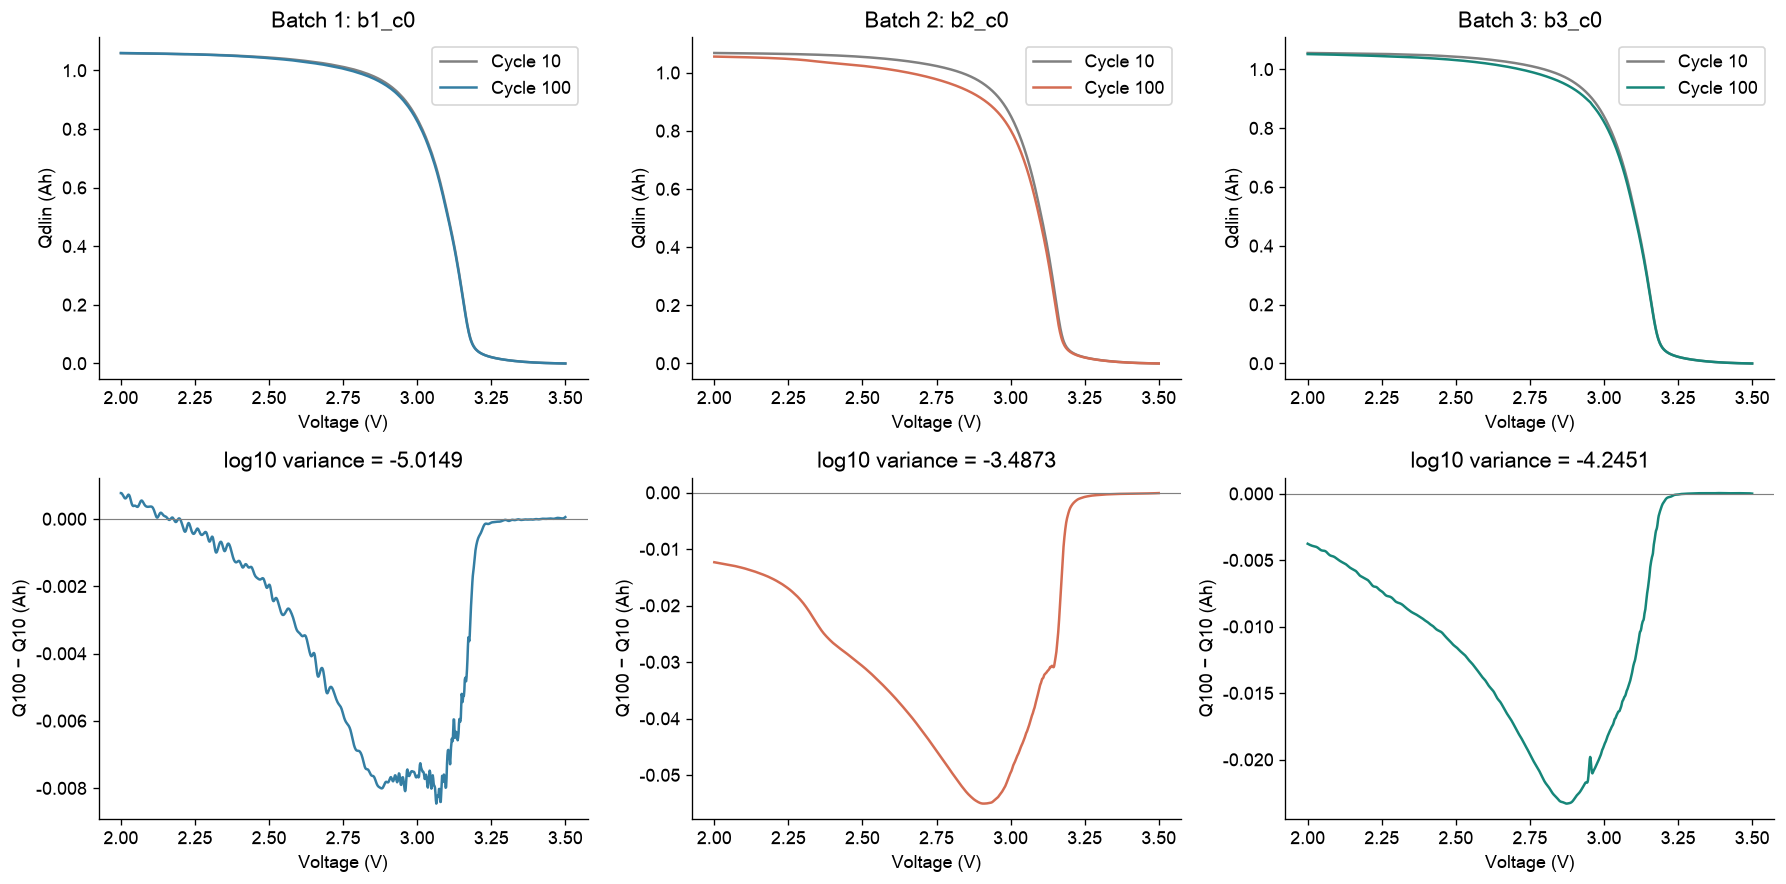

,batch_id,n,pearson,spearman
0,1,46,-0.8860,-0.8710
1,2,39,-0.9020,-0.7090
2,3,44,-0.7020,-0.7970


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for col, (batch_id, example) in enumerate(examples.items()):
    v = example['voltage']
    axes[0, col].plot(v, example['q10'], label='Cycle 10', color='gray')
    axes[0, col].plot(v, example['q100'], label='Cycle 100', color=PALETTE[batch_id])
    axes[0, col].set(title=f'Batch {batch_id}: {example["sample_id"]}', xlabel='Voltage (V)', ylabel='Qdlin (Ah)')
    axes[0, col].legend()
    axes[1, col].plot(v, example['delta'], color=PALETTE[batch_id])
    axes[1, col].axhline(0, color='gray', lw=.7)
    axes[1, col].set(title=f'log10 variance = {example["delta_logvar"]:.4f}',
                     xlabel='Voltage (V)', ylabel='Q100 − Q10 (Ah)')
fig.tight_layout(); show_and_save()

display(feature_data.raw_delta_correlations.round(3))
print('위 상관은 EDA 표본 129개 기준입니다. 품질 선별 125개 결과는 뒤에서 별도로 확인합니다.')


## 3. 핵심 피처: 충전 Policy 분해

예: `5.3C(54%)-4C-newstructure` → `C1=5.3`, `전환 SOC=54%`, `C2=4.0`.

| 변수 | 정의 | 처리 |
|---|---|---|
| `policy_C1` | 1차 충전 C-rate | 숫자 |
| `policy_switch_SOC_pct` | 1차→2차 전환 SOC | 0~100 백분율 숫자 |
| `policy_C2` | 2차 충전 C-rate | 숫자 |
| `charging_policy` | 원본 Policy 전체 문자열 | 범주형 대안 X |
| `policy_newstructure_label` | 원본 `-newstructure` 라벨 유무 | 선택적 0/1 확장 |

`newstructure`의 물리적 의미는 임의로 단정하지 않습니다.
기본 구조화 X에는 C1/SOC/C2만 넣고, 꼬리말 보존 버전은 별도로 제공합니다.
같은 명목 C-rate라도 원본 라벨·배치의 차이가 남을 수 있으므로 두 Policy 표현을 검증에서 비교해야 합니다.

In [4]:
display(feature_data.policy_preview)
print('C1/C2는 C-rate, 전환 SOC는 퍼센트입니다. 꼬리말은 원본 라벨로 보존합니다.')


C1/C2는 C-rate, 전환 SOC는 퍼센트입니다. 꼬리말은 원본 라벨로 보존합니다.


,charging_policy,policy_C1,policy_switch_SOC_pct,policy_C2,policy_newstructure_label
sample_id,,,,,
b1_c0,3.6C(80%)-3.6C,3.6000,80.0000,3.6000,0
b1_c3,4C(80%)-4C,4.0000,80.0000,4.0000,0
b1_c5,4.4C(80%)-4.4C,4.4000,80.0000,4.4000,0
b1_c6,4.8C(80%)-4.8C,4.8000,80.0000,4.8000,0
b1_c8,5.4C(40%)-3.6C,5.4000,40.0000,3.6000,0
b1_c10,5.4C(50%)-3C,5.4000,50.0000,3.0000,0
b1_c12,5.4C(50%)-3.6C,5.4000,50.0000,3.6000,0
b1_c14,5.4C(60%)-3C,5.4000,60.0000,3.0000,0
b1_c16,5.4C(60%)-3.6C,5.4000,60.0000,3.6000,0


## 4. 품질 플래그와 표본 범위 분리

**기본 피처 후보 표본:** 수명 유효 129개에서 Batch 3 원본 ID `{2,37,42,43}`을 제외한 **잠정 125개**.
이는 원본 품질 플래그에 따른 제외이며 목표 수명값을 기준으로 제거하는 처리는 아닙니다.

**종단 라벨 점검:** 기록 마지막 Qd가 `0.885 Ah`를 넘는 셀은 기존 종단 convention을 바탕으로 확인 후보로 표시합니다.
이 기준은 개별 배터리의 진짜 80% SOH 판정 기준이 아니며, 중도 종료를 확정하지도 않습니다.
종단 정보는 **메타데이터와 민감도 표본에만** 사용합니다.
이 후보를 추가 제외한 **115개**는 별도 민감도 데이터로 보관합니다.
원본 라벨을 관측 길이로 대체하거나 누락된 최종 수명을 추정하지 않습니다.

In [5]:
selected, conservative = feature_data.selected, feature_data.conservative
display(feature_data.sample_scope)
display(selected.groupby('batch_id').size().rename('default_rows'))
print('기본 표본에서 제외한 원본 품질 ID:')
display(feature_data.excluded_quality[['batch_id','cell_id','charging_policy','known_collection_issue','author_quality_flag']])
print('종단 라벨 확인 후보 (입력 X에는 포함하지 않음):')
display(selected.loc[selected.endpoint_review_candidate,
                     ['batch_id','cell_id','cycle_life','last_QD','last_cycle','last_to_initial_ratio']])


기본 표본에서 제외한 원본 품질 ID:
종단 라벨 확인 후보 (입력 X에는 포함하지 않음):


,scope,n
0,Labelled feature extraction,129
1,Default: exclude Batch3 quality flags,125
2,Sensitivity: also exclude endpoint review candidates,115


,default_rows
batch_id,
1,46
2,39
3,40


,batch_id,cell_id,charging_policy,known_collection_issue,author_quality_flag
sample_id,,,,,
b3_c2,3,2,5.6C(19%)-4.6C-newstructure,False,True
b3_c37,3,37,4.8C(80%)-4.8C-newstructure,True,True
b3_c42,3,42,4.8C(80%)-4.8C-newstructure,False,True
b3_c43,3,43,5C(67%)-4C-newstructure,False,True


,batch_id,cell_id,cycle_life,last_QD,last_cycle,last_to_initial_ratio
sample_id,,,,,,
b1_c0,1,0,1190,1.0262,1189,0.9534
b1_c1,1,1,1179,1.0382,1178,0.9596
b1_c2,1,2,1177,1.0433,1176,0.9610
b1_c3,1,3,1226,0.9709,1225,0.8949
b1_c4,1,4,1227,1.0220,1226,0.9439
b1_c8,1,8,879,0.9690,878,0.8849
b1_c10,1,10,906,0.9610,905,0.8884
b1_c12,1,12,902,0.9131,901,0.8438
b1_c13,1,13,897,0.9231,896,0.8512


## 5. 기본·대안·확장 X와 y 만들기

| 데이터 | 구성 | 목적 |
|---|---|---|
| `X` / `X_structured` | ΔQ log variance + C1/SOC/C2 | 기본 숫자형 입력 |
| `X_baseline` | ΔQ log variance 단독 | Policy 추가 효과의 기준 |
| `X_categorical` | ΔQ log variance + 원본 Policy 문자열 | 전체 Policy 범주형 대안 |
| `X_structured_with_label` | 기본 X + 원본 newstructure 라벨 0/1 | 꼬리말 정보의 효과 확인 |
| `X_extended` | 기본 X + 초기 열화율·용량·온도·전류 | 추가 초기 신호 후보 |
| `X_optional` | ΔQ 최솟값·충전시간·IR | 대체/확장 실험용 |
| `y` | 제공된 cycle_life | 회귀 Target |

`batch_id`, `cell_id`, 품질/종단 플래그, 기록 길이, 후기 열화, Knee와 수명 그룹은 기본 입력에 넣지 않습니다.
`sample_id`는 `b{batch}_c{original_id}` 형태로 X·y의 행을 맞추는 인덱스이며 모델 피처가 아닙니다.

In [6]:
X, y, metadata = feature_data.X, feature_data.y, feature_data.metadata
X_variants = feature_data.X_variants
display(pd.DataFrame([{'variant':name,'rows':len(table),'columns':len(table.columns),
                       'features':', '.join(table.columns)} for name,table in X_variants.items()]))
display(X.head())
display(y.head())


,variant,rows,columns,features
0,X,125,4,"delta_logvar, policy_C1, policy_switch_SOC_pct, policy_C2"
1,X_baseline,125,1,delta_logvar
2,X_categorical,125,2,"delta_logvar, charging_policy"
3,X_structured_with_label,125,5,"delta_logvar, policy_C1, policy_switch_SOC_pct, policy_C2, policy_newstructure_label"
4,X_extended,125,9,"delta_logvar, policy_C1, policy_switch_SOC_pct, policy_C2, early_fade_rate, mean_QD, mean_Tavg, mean_charge_current, peak_charge_current"
5,X_optional,125,3,"delta_min, mean_chargetime, mean_IR"


,delta_logvar,policy_C1,policy_switch_SOC_pct,policy_C2
sample_id,,,,
b1_c0,-5.0149,3.6000,80.0000,3.6000
b1_c1,-5.0140,3.6000,80.0000,3.6000
b1_c2,-4.7370,3.6000,80.0000,3.6000
b1_c3,-4.4426,4.0000,80.0000,4.0000
b1_c4,-4.6477,4.0000,80.0000,4.0000


,cycle_life
sample_id,
b1_c0,1190
b1_c1,1179
b1_c2,1177
b1_c3,1226
b1_c4,1227


## 6. 피처 정의·결측·중복·상관 점검

추가 피처는 EDA 기반 후보이며 검증으로 선택된 최적 조합은 아닙니다.
`mean_Tmax`는 `mean_Tavg`와 중복이 커 기본 확장에서 제외합니다.
ΔQ 분산·로그분산·최솟값·면적을 모두 넣지 않고 기본에는 로그분산만 사용합니다.
IR 결측은 지금 채우지 않습니다. 모델링 때 학습 fold에서 정한 대체값을 평가 fold에 적용해야 합니다.

결측 대체·표준화·범주 인코더 fit은 수행하지 않았습니다.
Batch 3는 품질 선별 40개입니다. 원본 EDA 44개와 상관계수가 다릅니다.


,feature,formula,meaning,role
0,delta_logvar,"log10(var(Q100-Q10)), ddof=0",초기 방전곡선 변화,Core
1,policy_C1,원본 Policy 1차 C-rate,1차 충전 조건,Core
2,policy_switch_SOC_pct,원본 Policy 전환 SOC(%),전환 조건,Core
3,policy_C2,원본 Policy 2차 C-rate,2차 충전 조건,Core
4,charging_policy,원본 Policy 문자열,범주형 Policy 전체,Categorical alternative
5,policy_newstructure_label,원본 꼬리말 존재 여부(0/1),라벨 그룹 정보; 물리적 의미 단정 없음,Label alternative
6,early_fade_rate,10~100 Qd 직선 기울기의 음수(Ah/cycle),초기 감소/증가 속도,Extended
7,mean_QD,10~100 평균 Qd(Ah),초기 용량 수준,Extended
8,mean_Tavg,10~100 평균 Tavg(°C),초기 열 조건,Extended
9,mean_charge_current,사이클별 시간 가중 충전 전류 평균의 평균(A),지속 충전 강도,Extended


,missing_cells,missing_pct,unique_values
delta_logvar,0,0.0000,125
policy_C1,0,0.0000,15
policy_switch_SOC_pct,0,0.0000,19
policy_C2,0,0.0000,14
early_fade_rate,0,0.0000,125
mean_QD,0,0.0000,125
mean_Tavg,0,0.0000,125
mean_charge_current,0,0.0000,125
peak_charge_current,0,0.0000,125
delta_min,0,0.0000,125


,n,min_feature_cycle,max_feature_cycle,removed_time_gaps,removed_charge_spikes
batch_id,,,,,
1,46,10,100,59,3
2,39,10,100,39,10
3,44,10,100,1,0


,batch_id,feature,n,pearson,spearman
0,1,delta_logvar,46,-0.8860,-0.8710
1,1,policy_C1,46,-0.5800,-0.4830
2,1,policy_switch_SOC_pct,46,0.2350,0.1850
3,1,policy_C2,46,-0.0960,0.0470
4,1,early_fade_rate,46,-0.5240,-0.5780
5,1,mean_QD,46,0.2150,0.2410
6,1,mean_Tavg,46,-0.4860,-0.3710
7,1,mean_charge_current,46,-0.7720,-0.6880
8,1,peak_charge_current,46,-0.5800,-0.5150
9,1,delta_min,46,0.8820,0.8500


,feature,VIF,n
0,delta_logvar,2.1110,125
1,early_fade_rate,1.3060,125
2,mean_QD,1.9980,125
3,mean_Tavg,1.4910,125
4,mean_charge_current,1.3690,125
5,peak_charge_current,1.4280,125


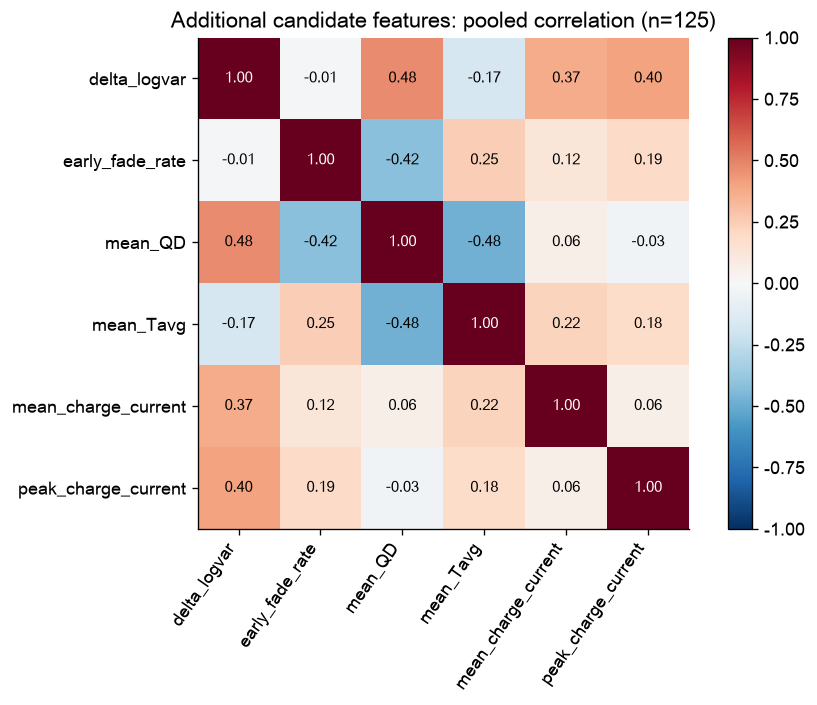

In [7]:
display(feature_data.feature_definitions)
display(feature_data.missing_summary)
print('결측 대체·표준화·범주 인코더 fit은 수행하지 않았습니다.')
display(feature_quality.groupby('batch_id').agg(
    n=('cell_id','size'), min_feature_cycle=('feature_cycle_min','min'),
    max_feature_cycle=('feature_cycle_max','max'),
    removed_time_gaps=('removed_time_gaps','sum'), removed_charge_spikes=('removed_charge_spikes','sum')))
display(feature_data.target_correlations.round(3))
print('Batch 3는 품질 선별 40개입니다. 원본 EDA 44개와 상관계수가 다릅니다.')
display(feature_data.candidate_vif.round(3))
candidate_numeric = ['delta_logvar']+ADDITIONAL
candidate_corr = feature_data.candidate_corr
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(candidate_corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(candidate_numeric)), candidate_numeric, rotation=55, ha='right')
ax.set_yticks(range(len(candidate_numeric)), candidate_numeric)
for i in range(len(candidate_numeric)):
    for j in range(len(candidate_numeric)):
        value = candidate_corr.iloc[i, j]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(value) > .65 else 'black')
ax.set_title('Additional candidate features: pooled correlation (n=125)')
fig.colorbar(im, ax=ax); fig.tight_layout(); show_and_save()


## 7. 모델링 전처리와 검증 연결

이 노트북은 고정 정의에 따른 피처를 추출하고 **변환 전 원본값**을 저장합니다.
모델링 시 배터리/Policy/배치를 기준으로 학습·평가를 분리한 후 다음 처리를 학습 fold에서만 fit하세요.

- Ridge: 숫자 피처의 결측 대체·StandardScaler, 범주형 Policy 대안은 OneHotEncoder.
- 트리 후보: 필요 결측 처리, 범주형 인코딩. 추가 스케일링 의존도는 낮습니다.
- 새로운 Policy가 평가에 존재하면 구조화 C1/SOC/C2와 범주형 Policy 표현의 차이를 비교합니다.
- 원본 Policy OneHotEncoder의 `handle_unknown='ignore'`는 미관측 범주를 처리하지만, 해당 정책의 개별 효과를 학습해 주지는 않습니다.
- `X_baseline → X_structured / X_categorical → X_extended` 순서로 추가 정보의 검증 효과를 확인합니다.

아래는 모델 학습 없이, 한 배치를 평가에 둘 때 미관측 원본 Policy가 얼마나 많은지 확인합니다.
숫자형 기본 X에서 `newstructure` 꼬리말을 빼면 서로 다른 원본 라벨이 같은 C1/SOC/C2로 합쳐지는 것도 점검합니다.

In [8]:
display(feature_data.policy_generalization)
collisions = feature_data.nominal_policy_collisions
display(collisions.loc[collisions.original_labels > 1])
display(Markdown(build_feature_report(feature_data)))


,held_out_batch,train_rows,test_rows,unseen_policy_cells,unseen_policy_pct
0,1,79,46,42,91.3043
1,2,86,39,29,74.3590
2,3,85,40,36,90.0000


,policy_C1,policy_switch_SOC_pct,policy_C2,original_labels
8,4.8000,80.0000,4.8000,2
11,5.2000,58.0000,4.0000,2
21,5.6000,26.0000,4.5000,2


# Feature Engineering 결과

- 원본 수명 유효 피처 129개, 품질 선별 기본 125개, 종단 점검 민감도 115개.
- 기본 X: delta_logvar, policy_C1, policy_switch_SOC_pct, policy_C2.
- 기본 숫자형 Policy는 C1/SOC/C2이며 원본 Policy 범주형과 꼬리말 보존 대안도 제공한다.
- Target: 제공된 cycle_life. 확정된 EOL 관측 표본만 있다고 가정하지 않는다.
- 피처 계산 구간: 실제 10~100사이클. ΔQ = Q100−Q10, log10(var), ddof=0.
- 확장 피처는 초기 열화율·용량·온도·전류이며 EDA 기반 후보다.
- Batch 3 기본40개에서 ΔQ 상관은 -0.742. 원본44개 EDA와 구분한다.
- 일부 IR 결측을 유지하고, 보간/표준화/OneHotEncoder는 학습 fold 안에서 fit해야 한다.
- Knee·후기 기울기·전체 기록 길이·수명 그룹·배치/셀 ID·품질/종단 플래그는 기본 X에서 제외한다.
- 정책 미관측 표는 기술적 진단이다. DAY 2 모델링은 Batch 1만 학습·튜닝하고 Batch 2를 테스트하며 Batch 3은 사용하지 않는다.
- 이 모듈은 모델을 학습하거나 검증 성능을 산출하지 않는다.
- 실행 노트북: notebooks/02_feature_engineering.ipynb. 기본 출력: data/processed.

## 8. X·y·메타데이터 저장

공통 저장 함수로 `data/processed`에 입력·타깃·메타데이터·점검 표를 저장합니다.
`src.train`과 `03_modeling.ipynb`가 같은 파일을 사용합니다.
재실행 시 생성 파일을 갱신합니다. 원본은 변경하지 않습니다.


In [9]:
save_feature_tables(feature_data, OUTPUT_DIR)
print('Saved:', OUTPUT_DIR)
print('X:', X.shape, 'y:', y.shape, 'sensitivity X:', feature_data.X_sensitivity.shape)


Saved: /Users/u079/skala/data-mini-project/data/processed
X: (125, 4) y: (125, 1) sensitivity X: (115, 4)
